In [ ]:
"""
The goal of this small notebook is to provide the code to implement a failsafe in case our main detection method fails.
We do so by taking the mean position and size of the optic disc, based on earlier stats. 
It is meant to be later integrated in the main pipeline of our code.
"""
import cv2
import pandas as pds
import matplotlib.pyplot as plt


In [ ]:
# Name of the image we want to test
img_name = "test_OG.jpg"

In [84]:
# load the image 
img = cv2.imread(img_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
# resize it
img = cv2.resize(img, (874, 538))
# Note : don't forget to install odfpy : pip install odfpy
df = pds.read_excel('stats_diametre.ods', sheet_name=None)

In [ ]:
# get the proper sheet to take the average of : we are either treating the right eye or the left eye 
if "OD" in img_name:
    current_sheet = df["OEIL DROIT"]
else: 
    current_sheet = df["OEIL GAUCHE"]

In [86]:
# Get the data neede to draw a circle on the image
len = current_sheet.pos_centre_x.size

pos_x = current_sheet.pos_centre_x[len-1]
pos_y = current_sheet.pos_centre_y[len-1]

diam_x = current_sheet.Diam_x_Rouge[len-1]
diam_y = current_sheet.Diam_y_Rouge[len-1]
diam = int((diam_x + diam_y)//2)

cv2.circle(img,(int(pos_x), int(pos_y)), diam, (255,0,0), 5)

array([[[12, 12, 12],
        [12, 12, 12],
        [13, 13, 13],
        ...,
        [12, 12, 14],
        [12, 12, 14],
        [12, 12, 14]],

       [[12, 12, 12],
        [12, 12, 12],
        [12, 12, 12],
        ...,
        [13, 13, 15],
        [12, 12, 14],
        [12, 12, 14]],

       [[12, 12, 12],
        [12, 12, 12],
        [12, 12, 12],
        ...,
        [13, 13, 15],
        [12, 12, 14],
        [12, 12, 14]],

       ...,

       [[14, 14, 16],
        [12, 12, 14],
        [10, 10, 12],
        ...,
        [10, 10, 12],
        [12, 12, 14],
        [12, 12, 14]],

       [[12, 12, 14],
        [12, 12, 14],
        [12, 12, 14],
        ...,
        [12, 12, 14],
        [12, 12, 13],
        [12, 12, 14]],

       [[12, 12, 14],
        [13, 13, 15],
        [14, 14, 14],
        ...,
        [12, 12, 14],
        [12, 12, 14],
        [14, 14, 16]]], dtype=uint8)

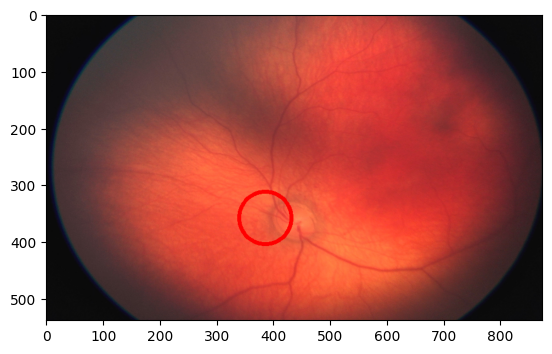

In [ ]:
# Show the final result

plt.plot()
plt.imshow(img)
plt.show()